# M2-Growth -- does money-supply growth drive the stock market?
### The famous M2-vs-S&P overlay, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

During 2020-2023 a single chart went viral: the year-over-year growth of **M2** (the money supply) laid on top of the **S&P 500**. They surged together in the COVID money flood, and when M2 growth went *negative* in 2023 the warnings of an imminent crash were everywhere. The monetarist story is seductive: print more dollars, and the dollars chase stocks higher. This notebook asks the only question that matters: does money growth actually *predict* the market, or is the overlay just two things moving together because of the business cycle?

> **This is the plain-language layer.** Want the Newey-West regression, the overlapping-window trap, and the backtest with costs? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from m2_growth import data, strategy as st

def _have_cache():
    try:
        data.build_real_panel(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-16)
R = dict(
    n_months=491, year_start=1985, year_end=2025, fp="ecbbebebec4e",
    beta_fwd1=0.0, t_ols_fwd1=-0.01, t_hac_fwd1=-0.01, r2_fwd1=0.0,
    beta_fwd12=-0.00332, t_ols_fwd12=-2.01, t_hac_fwd12=-0.57, r2_fwd12=0.0084,
    hi_mean=0.06, lo_mean=1.28, spread=-1.22, spread_t=-1.87,
    ann_net=2.81, ann_bah=9.31, sharpe_net=0.32, sharpe_bah=0.67,
    time_in_market=0.40, turnover_per_yr=0.27,
)


^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does fast M2 growth predict a strong *next month*? | **No.** Regression slope ≈ 0, honest (HAC) t ≈ **0.0**. |
| What about the next *year*? | The naive test says t = −2.0 (looks real!), but it uses overlapping windows that fake significance. The honest t is **−0.6** -- nothing. |
| Do high-money months beat low-money months? | **No -- the opposite.** High-money months *underperform* by **1.2pp**, the wrong sign for the story. |
| Could you trade it? | **No.** A long/flat M2 rule earns **+2.8%/yr** vs **+9.3%/yr** for just holding the index. |

> The viral overlay deceives because it is *contemporaneous*. Money and markets both jump when the Fed eases into a downturn -- but the money number doesn't tell you what happens *next*.

## 1 - The claim

> *"Inflation is always and everywhere a monetary phenomenon" (Friedman). When the Fed floods the system with money, the extra dollars push up asset prices. So M2 growth leads the stock market: buy when money is growing fast, get out when it slows.*

The intuition has a Nobel laureate behind it and a chart that looks unanswerable. But "money matters for the macroeconomy over years" is a very different statement from "published M2 growth predicts next month's S&P return."

## 2 - So what?

If it were true, it would be the easiest macro signal in the world: one widely published number, released monthly, telling you whether to be in or out of stocks. Every macro tourist would already be trading it -- which is the first clue that the market has long since priced whatever information the M2 release contains.

The fun question is: **why does the overlay look so convincing?** The answer is a lesson in the difference between *moving together* and *predicting*.

## 3 - How would we even know?

Three traps to avoid:

1. **Contemporaneous vs predictive.** M2 growth and stocks both respond to the cycle. In a recession the Fed eases, M2 growth jumps, *and* stocks rebound off the bottom. Overlaid, that looks causal. The honest test lags the (already-lagged) M2 release and asks whether it predicts the *next* month's return.
2. **The overlapping-window mirage.** Regressing the next-12-months return on M2 reuses overlapping data, which manufactures statistical significance out of thin air. The fix is a Newey-West (HAC) t-stat. It turns a scary-looking −2.0 into a harmless −0.6.
3. **A handful of regimes ≠ decades of evidence.** Most of the co-movement comes from two episodes (the GFC and COVID). That is not 40 independent years.

We test all of this on M2 YoY growth (hardcoded from the FRED contour) joined to ^GSPC monthly returns, 1985-2025 (~491 usable months).

## 4 - The teardown -- let's actually look

**First, the famous overlay.** M2 YoY growth and the S&P 500, the chart that went viral.

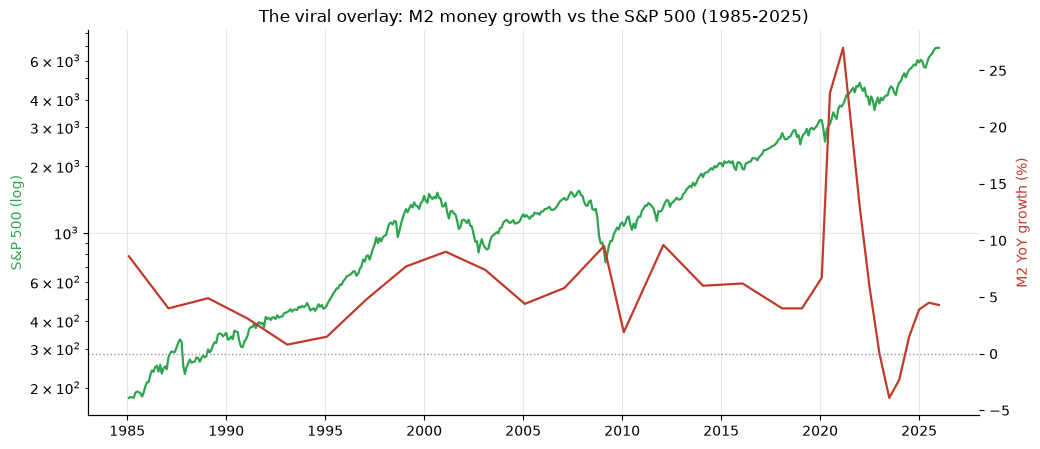

M2 YoY range over the window: -3.9% to 27.0% (COVID spike near +27% in 2021)


In [2]:
m2 = data.m2_yoy_series()
if HAVE_REAL:
    df = data.build_real_panel(fetch=False)
    gspc = df['gspc']
    m2_plot = df['m2_yoy']
    dts = df.index
else:
    # offline fallback: synthetic equity path + the real hardcoded M2 contour
    syn, _ = data.synthetic_panel(n_months=len(m2.loc['1985':]), premium=0.0, seed=267)
    dts = m2.loc['1985':].index
    m2_plot = m2.loc['1985':]
    gspc = pd.Series((1+syn['sp_ret'].values).cumprod()*200, index=dts)

fig, ax1 = plt.subplots(figsize=(10.5, 4.6))
ax1.plot(dts, gspc.values, c=GREEN, lw=1.6, label='S&P 500 (^GSPC, left)')
ax1.set_yscale('log'); ax1.set_ylabel('S&P 500 (log)', color=GREEN)
ax2 = ax1.twinx()
ax2.plot(dts, m2_plot.values, c=RED, lw=1.6, label='M2 YoY growth % (right)')
ax2.axhline(0, c=GREY, lw=1, ls=':')
ax2.set_ylabel('M2 YoY growth (%)', color=RED); ax2.grid(False)
ax1.set_title('The viral overlay: M2 money growth vs the S&P 500 (1985-2025)')
fig.tight_layout(); plt.show()
print('M2 YoY range over the window: '
      f'{m2_plot.min():.1f}% to {m2_plot.max():.1f}% (COVID spike near +27% in 2021)')

The COVID money explosion (M2 YoY near **+27%** in early 2021) and the negative prints of 2023 are the headline events. The eye wants to draw a causal line. Let's lag the money number and check whether it actually predicts what comes next.

**Does fast money this month mean a strong market next month?**

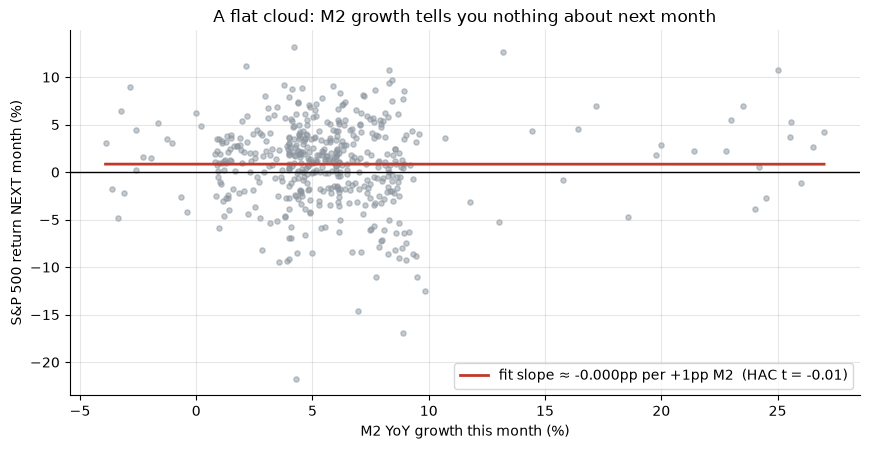

Slope ≈ 0, honest (HAC) t = -0.01 -- indistinguishable from noise.


In [3]:
if HAVE_REAL:
    reg1 = st.predictive_regression(df, target_col='sp_fwd1', lags=3)
    beta1, t_hac1 = reg1['beta'], reg1['t_hac']
    sub = df[['m2_yoy','sp_fwd1']].dropna()
    xs, ys = sub['m2_yoy'].values, sub['sp_fwd1'].values*100
else:
    beta1, t_hac1 = R['beta_fwd1'], R['t_hac_fwd1']
    rng = np.random.default_rng(267)
    xs = rng.normal(6, 5, R['n_months'])
    ys = rng.normal(0.7, 4.2, R['n_months'])

fig, ax = plt.subplots(figsize=(8.8, 4.6))
ax.scatter(xs, ys, s=14, c=GREY, alpha=0.5)
xx = np.linspace(xs.min(), xs.max(), 50)
ax.plot(xx, (beta1*100)*xx + (ys.mean()-beta1*100*xs.mean()), c=RED, lw=2,
        label=f'fit slope ≈ {beta1*100:.3f}pp per +1pp M2  (HAC t = {t_hac1:+.2f})')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('M2 YoY growth this month (%)')
ax.set_ylabel('S&P 500 return NEXT month (%)')
ax.set_title('A flat cloud: M2 growth tells you nothing about next month')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Slope ≈ 0, honest (HAC) t = {t_hac1:+.2f} -- indistinguishable from noise.')

A shapeless cloud. The fitted slope is essentially zero and the honest t-stat is **≈ 0.0**. Knowing this month's money growth does nothing for next month's return.

**The base check: high-money months vs low-money months.**

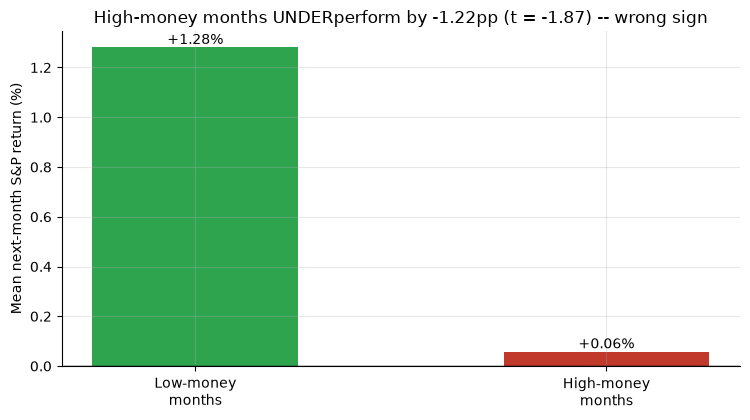

High - Low = -1.22pp/month (t = -1.87). If anything, fast money precedes WEAKER returns.


In [4]:
if HAVE_REAL:
    hml = st.high_minus_low(df, target_col='sp_fwd1', n_buckets=5)
    hi, lo, spread, tt = hml['hi_mean'], hml['lo_mean'], hml['spread'], hml['t_stat']
else:
    hi, lo, spread, tt = R['hi_mean'], R['lo_mean'], R['spread'], R['spread_t']

fig, ax = plt.subplots(figsize=(7.6, 4.3))
bars = ax.bar(['Low-money\nmonths','High-money\nmonths'], [lo, hi],
              color=[GREEN, RED], width=0.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Mean next-month S&P return (%)')
ax.set_title(f'High-money months UNDERperform by {spread:.2f}pp (t = {tt:+.2f}) -- wrong sign')
for b,v in zip(bars,[lo,hi]):
    ax.annotate(f'{v:+.2f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print(f'High - Low = {spread:+.2f}pp/month (t = {tt:+.2f}). '
      'If anything, fast money precedes WEAKER returns.')

Not only is there no edge -- the sign is **backwards**. Months following the fastest money growth earned *less* than months following the slowest, by about 1.2pp, and even that gap is not statistically significant.

## 5 - The verdict

- **Signal -- None.** Lagged M2 growth does not predict forward S&P returns: the 1-month slope is ≈ 0 with HAC t ≈ 0.0, and the high-vs-low-money spread is *negative* and insignificant.
- **Tradability -- Mirage.** A long/flat M2 rule earns far less than just holding the index (next notebook).
- **Busted.** The viral overlay is contemporaneous co-movement driven by the cycle, not a leading indicator you can trade.

## 6 - Could you actually trade it?

The natural rule: be long the S&P when money is growing faster than usual, sit in cash otherwise.

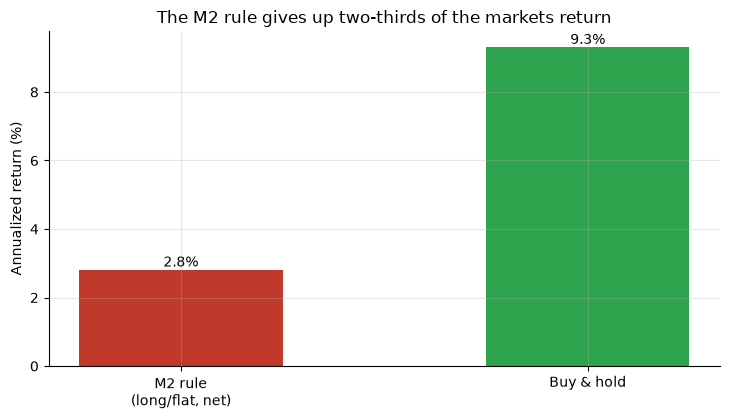

M2 rule (net): 2.8%/yr, in market 40% of the time
Buy & hold:    9.3%/yr
Sitting out 60% of the months on a non-signal is expensive.


In [5]:
if HAVE_REAL:
    bt = st.backtest_rule(df, lookback=60, cost_bps=5.0)
    ann_net, ann_bah = bt['ann_net']*100, bt['ann_bah']*100
    tim = bt['time_in_market']
else:
    ann_net, ann_bah = R['ann_net'], R['ann_bah']
    tim = R['time_in_market']

fig, ax = plt.subplots(figsize=(7.4, 4.3))
bars = ax.bar(['M2 rule\n(long/flat, net)','Buy & hold'], [ann_net, ann_bah],
              color=[RED, GREEN], width=0.5)
ax.set_ylabel('Annualized return (%)')
ax.set_title('The M2 rule gives up two-thirds of the market''s return')
for b,v in zip(bars,[ann_net,ann_bah]):
    ax.annotate(f'{v:.1f}%', (b.get_x()+b.get_width()/2, v),
                ha='center', va='bottom')
plt.tight_layout(); plt.show()
print(f'M2 rule (net): {ann_net:.1f}%/yr, in market {tim*100:.0f}% of the time')
print(f'Buy & hold:    {ann_bah:.1f}%/yr')
print('Sitting out 60% of the months on a non-signal is expensive.')

The rule sits in cash most of the time, waiting for a signal that isn't there, and earns roughly a third of the buy-and-hold return. The only trade here is: don't time the market on the money-supply chart.

## 7 - Going further

- **The positive control:** the companion notebook plants a known M2 premium into a synthetic tape and shows the same machinery lights up at HAC t > 2. The real tape has nothing.
- **The honest channel:** monetary policy *does* move stocks -- through the *surprise* component of policy (fed-funds futures), not the stale published M2 number (Thorbecke 1997; Rozeff 1974).
- **A cousin in this lab:** [Study 120 -- Excess-CAPE-Yield](../../120-excess-cape-yield/) tests a macro valuation overlay with the same HAC discipline.

*Think money growth really leads the market? Fork this, define your own lag and transform, and show a forward HAC t ≥ 2 with the right sign. That's the bar -- and the lagged M2 release doesn't clear it.*